In [2]:
from faker import Faker 

In [1]:
pip install Faker

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd 

In [4]:
import random 

In [5]:
fake = Faker ("es_MX")

In [6]:
#generamos datos sinteticos: 100 registros 

datos = []
for i in range (100):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo":fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100,50000),
        "plataforma": random.choice(
            ["TikTok","Intagram", "YouTube"]
        )
    })

In [7]:
df= pd.DataFrame(datos)
df.head

<bound method NDFrame.head of     id_usuario                         nombre                     correo  \
0            1        Gloria Esperanza Campos      minerva10@example.net   
1            2       Bruno Aurelio de la Crúz   murillopilar@example.net   
2            3          Federico René Serrato          zrico@example.org   
3            4  Aida Dulce Villanueva Aguilar     santiago44@example.org   
4            5   José Manuél Jonás Mora Gaona      abigail79@example.org   
..         ...                            ...                        ...   
95          96                Graciela Rincón     kfernandez@example.com   
96          97         Gustavo Zeferino Garay  sanabriarocio@example.org   
97          98                Graciela Pineda        ichacon@example.net   
98          99  Enrique Samuel Laboy Meléndez  maria-elena63@example.net   
99         100                    Irma Macías      pcalvillo@example.com   

    edad  seguidores plataforma  
0     47        7447   

In [8]:
#exploracion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [9]:
#estadisticas descriptivas
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.000000,100.00000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Gloria Esperanza Campos,minerva10@example.net,NaN,NaN,TikTok
freq,NaN,1,1,NaN,NaN,36
mean,50.500000,NaN,NaN,40.210000,25191.43000,NaN
std,29.011492,NaN,NaN,14.547932,14454.90921,NaN
min,1.000000,NaN,NaN,18.000000,369.00000,NaN
25%,25.750000,NaN,NaN,27.000000,12246.25000,NaN
50%,50.500000,NaN,NaN,39.500000,26268.50000,NaN
75%,75.250000,NaN,NaN,52.250000,38433.50000,NaN


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

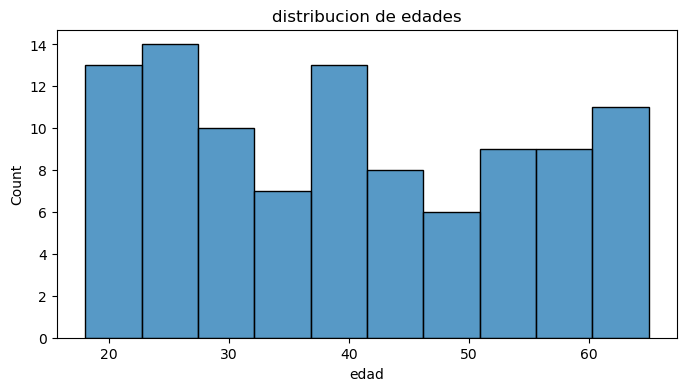

In [12]:
#distribucion de edades 

plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
    
)

plt.title("distribucion de edades" )
plt.show()

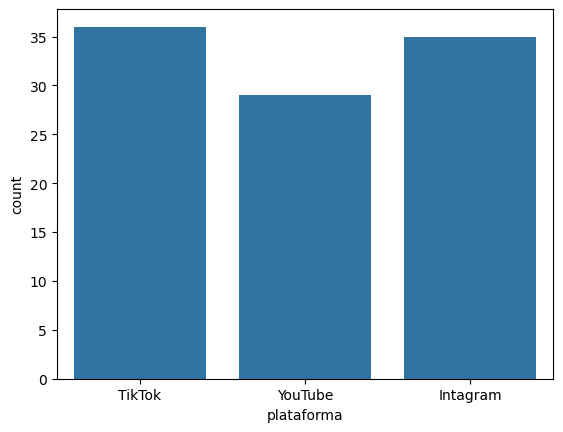

In [13]:
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [14]:
df_sucio = df.copy()

In [18]:
#le colocamos valores nulos 
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "nombre"] = None

In [20]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [21]:
#edades invalidas

for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"]=10

In [22]:
df_sucio.describe()["edad"]

count    100.000000
mean      37.800000
std       15.292436
min       10.000000
25%       25.750000
50%       37.500000
75%       50.500000
max       65.000000
Name: edad, dtype: float64

In [23]:
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"seguidores"]= 500000

In [24]:
df_sucio.describe()["seguidores"]

count       100.000000
mean      48746.790000
std      105023.337072
min         369.000000
25%       13286.500000
50%       26879.500000
75%       39362.000000
max      500000.000000
Name: seguidores, dtype: float64

In [28]:
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"correo"]= "correo_invalido"

In [30]:
df_sucio.describe(include=["string", "object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,91,3
top,Gloria Esperanza Campos,correo_invalido,TikTok
freq,1,10,36


In [32]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [33]:
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,95,100,100.000000,100.000000,100
unique,NaN,95,91,NaN,NaN,3
top,NaN,Gloria Esperanza Campos,correo_invalido,NaN,NaN,TikTok
freq,NaN,1,10,NaN,NaN,36
mean,50.500000,NaN,NaN,37.800000,48746.790000,NaN
std,29.011492,NaN,NaN,15.292436,105023.337072,NaN
min,1.000000,NaN,NaN,10.000000,369.000000,NaN
25%,25.750000,NaN,NaN,25.750000,13286.500000,NaN
50%,50.500000,NaN,NaN,37.500000,26879.500000,NaN
75%,75.250000,NaN,NaN,50.500000,39362.000000,NaN
